Saving Screenshot 2025-07-11 083035.png to Screenshot 2025-07-11 083035.png


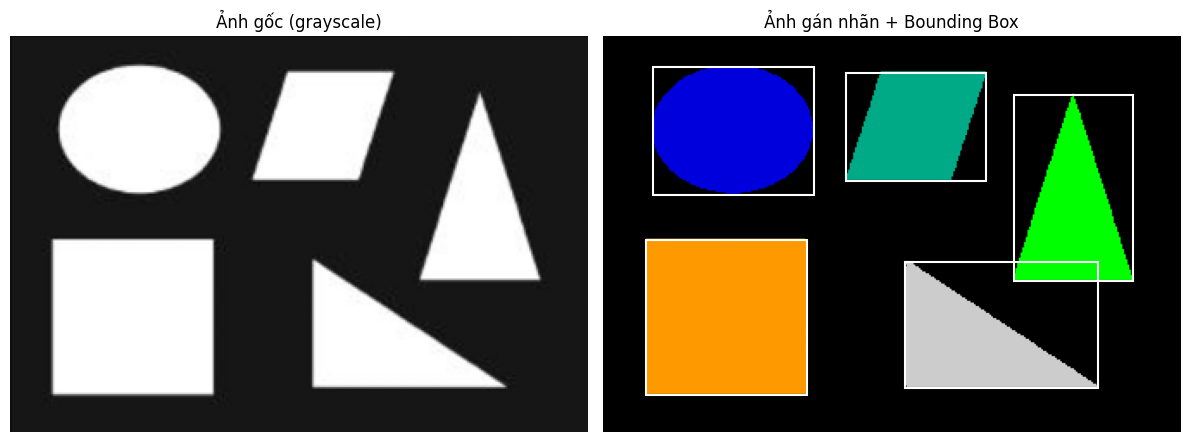

In [4]:
#2.1.	Gán nhãn ảnh
from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import imageio.v2 as iio
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters import threshold_otsu

data = Image.open(next(iter(uploaded))).convert('L')
a = np.asarray(data)
thres = threshold_otsu(a)
b = a > thres
c = label(b)
c1 = Image.fromarray((c * (255 // c.max())).astype(np.uint8))
iio.imsave('label_output.jpg', c1)
d = regionprops(c)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(a, cmap='gray')
axs[0].set_title('Ảnh gốc (grayscale)')
axs[0].axis('off')

axs[1].imshow(c, cmap='nipy_spectral')
axs[1].set_title('Ảnh gán nhãn + Bounding Box')
axs[1].axis('off')

for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rect = mpatches.Rectangle((lc, lr), uc - lc, ur - lr, fill=False, edgecolor='white', linewidth=1.5)
    axs[1].add_patch(rect)

plt.tight_layout()
plt.show()

Saving geometric.png to geometric (2).png


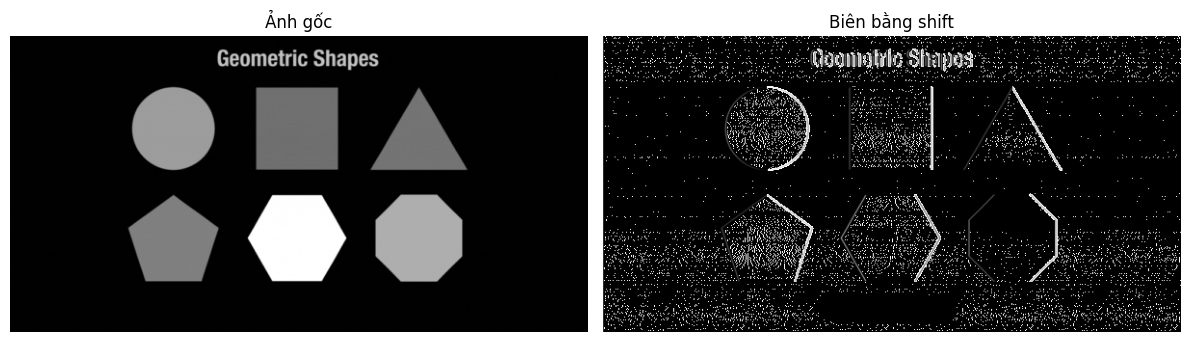

In [6]:
#2.2.	Dò tìm cạnh theo chiều dọc
from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

data = Image.open(next(iter(uploaded))).convert('L')
a = np.asarray(data)
bmg = np.abs(a - nd.shift(a, (0, 1), order=0))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(a, cmap='gray')
axs[0].set_title('Ảnh gốc')
axs[0].axis('off')
axs[1].imshow(bmg, cmap='gray')
axs[1].set_title('Biên bằng shift')
axs[1].axis('off')
plt.tight_layout()
plt.show()


Saving geometric.png to geometric (3).png


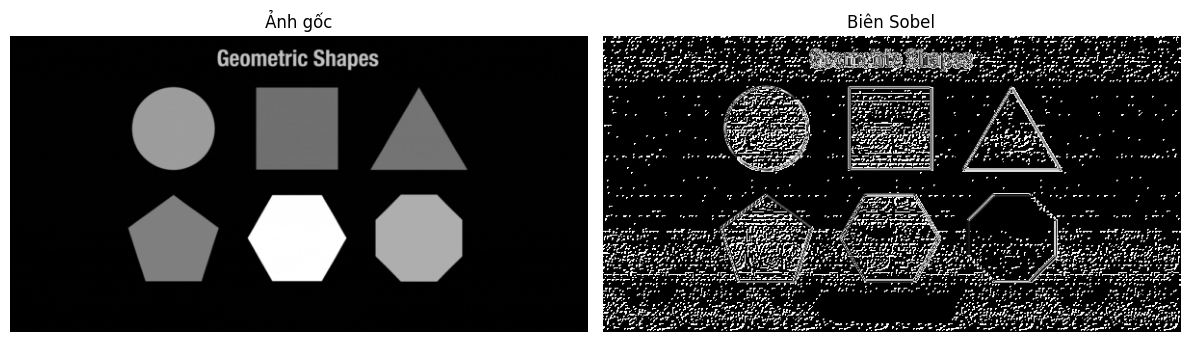

In [7]:
#2.3.	Dò tìm cạnh với Sobel Filter
from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

data = Image.open(next(iter(uploaded))).convert('L')
a = np.asarray(data)
sx = nd.sobel(a, axis=0)
sy = nd.sobel(a, axis=1)
bmg = np.abs(sx) + np.abs(sy)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(a, cmap='gray')
axs[0].set_title('Ảnh gốc')
axs[0].axis('off')
axs[1].imshow(bmg, cmap='gray')
axs[1].set_title('Biên Sobel')
axs[1].axis('off')
plt.tight_layout()
plt.show()


Saving Screenshot 2025-07-11 083653.png to Screenshot 2025-07-11 083653 (2).png


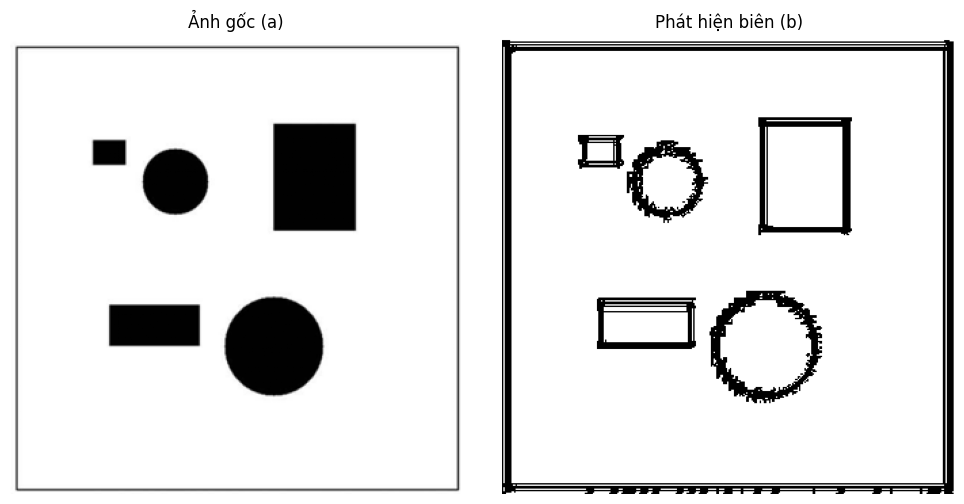

In [13]:
#2.4.	Xác định góc của đối tượng
from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

def sobel_edge(indata):
    sx = nd.sobel(indata, axis=0)
    sy = nd.sobel(indata, axis=1)
    edge = np.hypot(sx, sy)
    return edge

img = Image.open(next(iter(uploaded))).convert('L')
a = np.asarray(img)
edge = sobel_edge(a)

background = np.full_like(a, 128)
overlay = np.clip(edge, 0, 255).astype(np.uint8)
result = background.copy()
result[overlay > 30] = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(a, cmap='gray')
axs[0].set_title('Ảnh gốc (a)')
axs[0].axis('off')
axs[1].imshow(result, cmap='gray')
axs[1].set_title('Phát hiện biên (b)')
axs[1].axis('off')
plt.tight_layout()
plt.show()


Saving Screenshot 2025-07-11 083653.png to Screenshot 2025-07-11 083653 (3).png


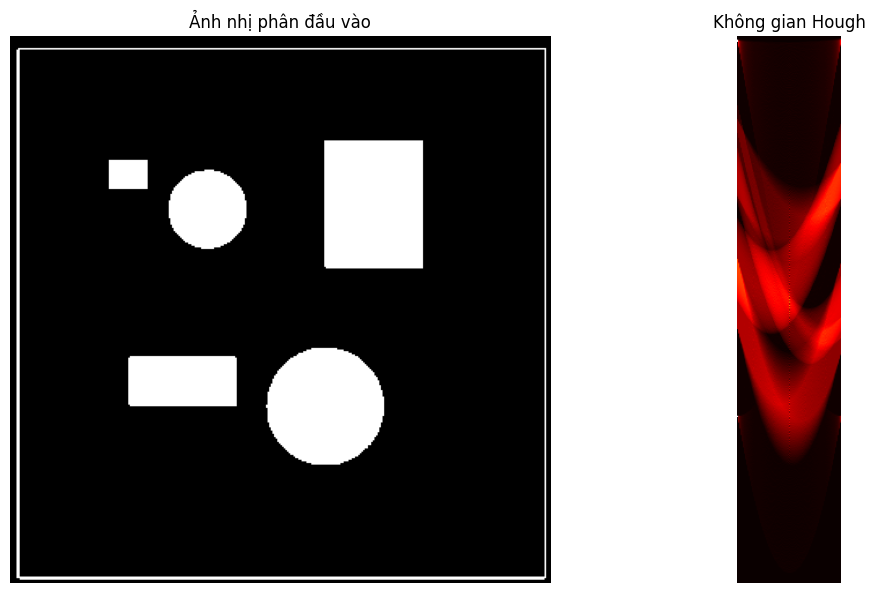

In [15]:
#2.5.1.	Dò tìm đường thẳng trong ảnh
from google.colab import files
uploaded = files.upload()

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import scipy.ndimage as nd

def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float)
    w = data + 0
    ok = 1
    theta = np.arange(90)/180.0 * np.pi
    tp = np.arange(90).astype(float)

    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v, h = divmod(w.argmax(), H)
            y = V - v
            x = h
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v,h] = 0
    return ho

img = Image.open(next(iter(uploaded))).convert('L')
a = np.array(img)
a_bin = (a < 128).astype(float)

bmg = LineHough(a_bin, 0.5)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(a_bin, cmap='gray')
axs[0].set_title('Ảnh nhị phân đầu vào')
axs[0].axis('off')
axs[1].imshow(bmg, cmap='hot', extent=[0, 90, 0, np.sqrt(a.shape[0]**2 + a.shape[1]**2)])
axs[1].set_title('Không gian Hough')
axs[1].axis('off')
plt.tight_layout()
plt.show()


Saving Screenshot 2025-07-11 083653.png to Screenshot 2025-07-11 083653 (5).png


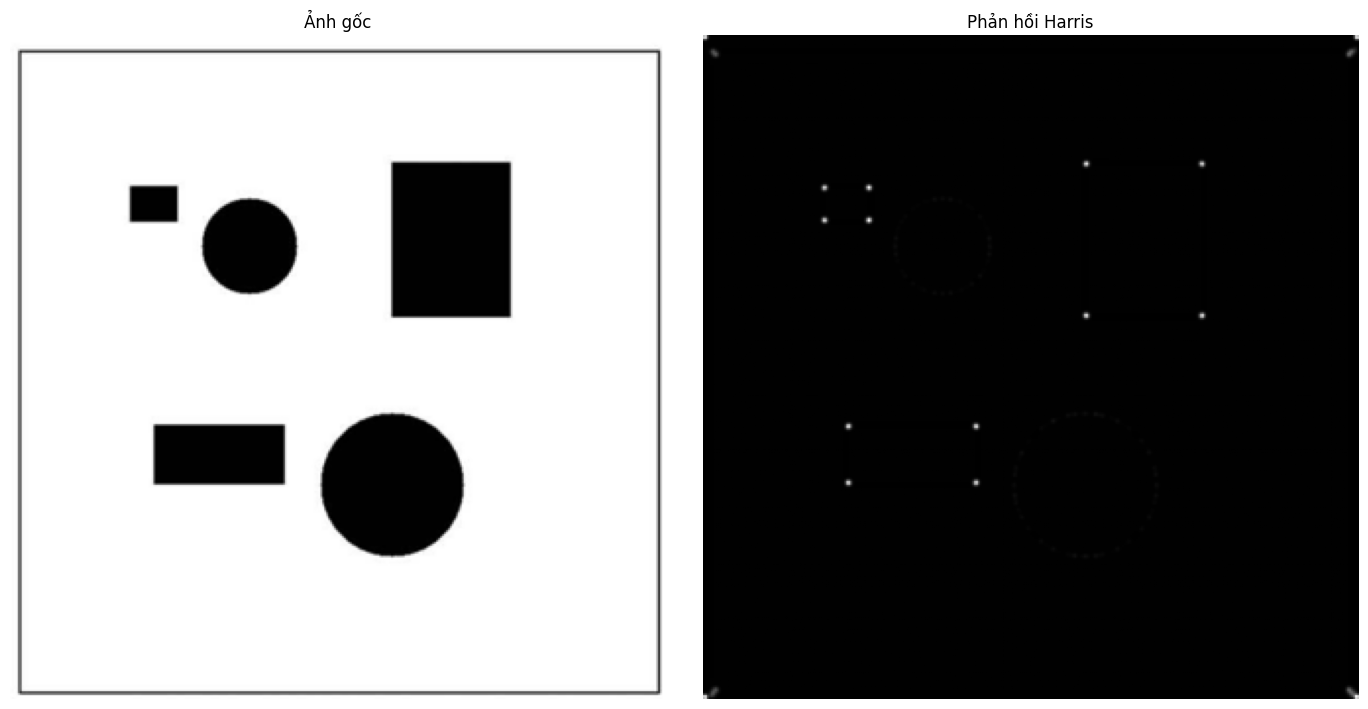

In [17]:
#2.5.2.	Dò tìm đường tròn trong ảnh
from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris
from skimage.color import rgb2gray
import imageio.v2 as iio

data = iio.imread(next(iter(uploaded)))
image_rgb = data[:, :, :3]
image_gray = rgb2gray(image_rgb)
corner_response = corner_harris(image_gray, k=0.001)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(image_rgb)
axs[0].set_title('Ảnh gốc')
axs[0].axis('off')
axs[1].imshow(corner_response, cmap='gray')
axs[1].set_title('Phản hồi Harris')
axs[1].axis('off')
plt.tight_layout()
plt.show()


Saving Screenshot 2025-07-11 083653.png to Screenshot 2025-07-11 083653 (7).png
Saving Screenshot 2025-07-11 083035.png to Screenshot 2025-07-11 083035 (2).png


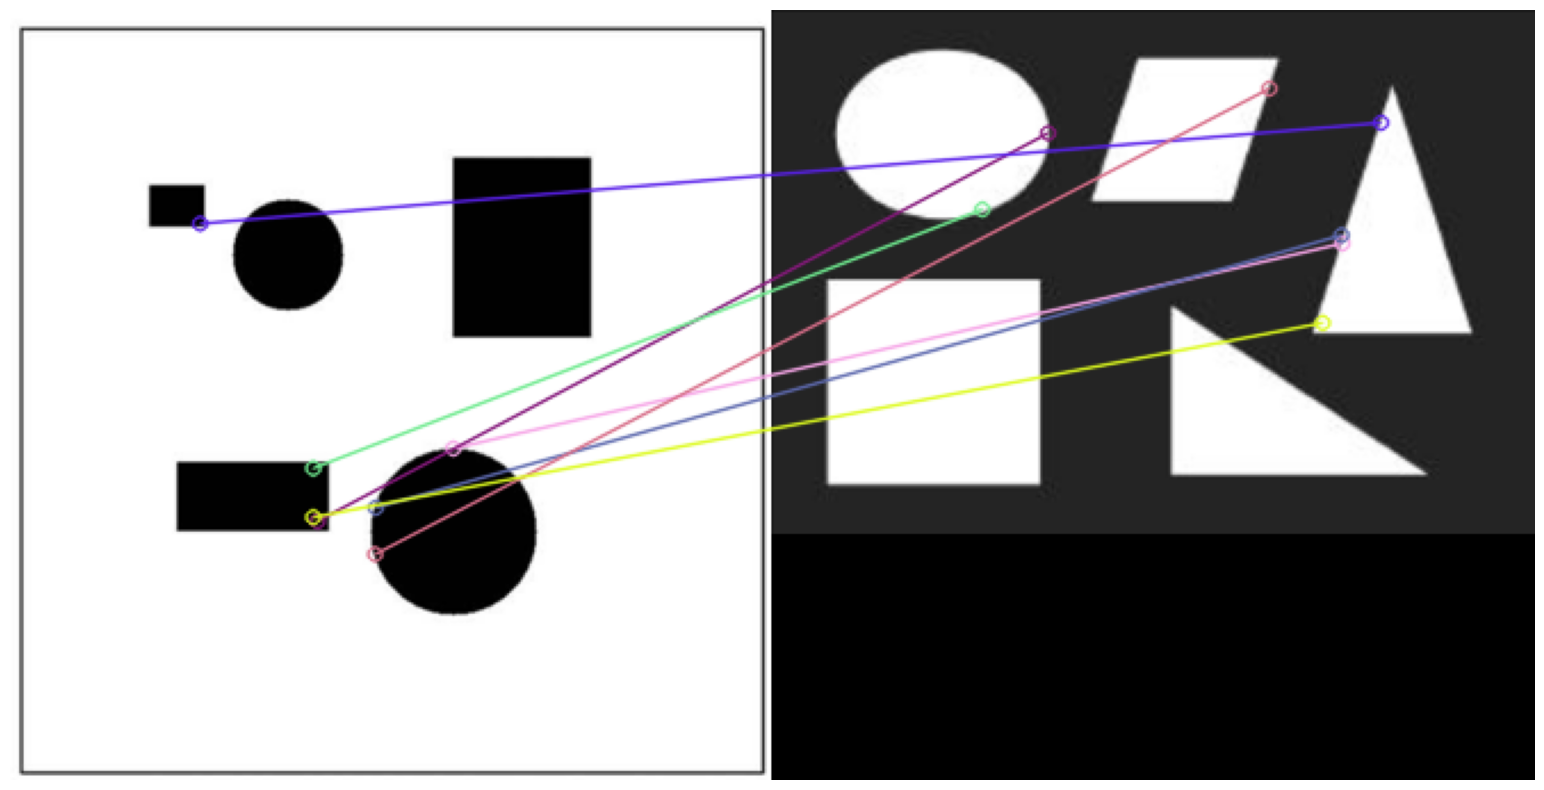

In [21]:
#2.6.	Image matching
from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np
import matplotlib.pyplot as plt

keys = list(uploaded.keys())
if len(keys) < 2:
    print("Cần upload 2 ảnh để so sánh.")
else:
    img1 = cv2.imread(keys[0])
    img2 = cv2.imread(keys[1])

    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    result = cv2.drawMatches(img1, kp1, img2, kp2, matches[:30], None, flags=2)

    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
